Copyright (C) [2025] Instituto Nacional de Estadística

Este archivo forma parte del proyecto statcodgen.

Licenciado bajo la Licencia Pública de la Unión Europea (EUPL) v.1.2.
Puede obtener una copia de la licencia en la raiz de este proyecto o en:
https://eupl.eu/1.2/es/

A menos que se indique lo contrario, este software se distribuye 
"TAL CUAL", SIN GARANTÍAS NI CONDICIONES DE NINGÚN TIPO.
Consulte la licencia para conocer los términos específicos.

------------------------------------------------------------------------------
Copyright (C) [2025] National Institute of Statistics

This file is part of the statcodgen project.

Licensed under the European Union Public License (EUPL) v.1.2.
You can obtain a copy of the license at the root of this project or at:
https://eupl.eu/1.2/es/

Unless otherwise indicated, this software is distributed
"AS IS", WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND.
See the license for specific terms.

In [2]:
# Python libraries to be used for the examples
import re
import os
import pandas as pd
import random

from statcodgen import Codifier
from statcodgen import Structured
from statcodgen import CodifierFastText
from statcodgen import StructuredCNAE
# As CodifierBERT is optional and requires additional dependencies,
# we need to specify where it should be imported from:
# from statcodgen.codifier_bert import CodifierBERT # Do not run this line if you have not installed the additional dependencies.

#### All the explanations in this tutorial are first in Spanish and then translated into English.

# Tutorial Statcodgen
- [Clases básicas de statcodgen](#Clases-básicas-de-statcodgen)
- [Uso de structured](#Uso-de-Structured)
- [Uso de Codifier](#Uso-de-Codifier)
    - [CodifierFastText](#CodifierFastText)
    - [CodifierBERT](#CodifierBERT)

--------------------------------------------------------------------------------------------------------------------------------------------------------
# Tutorial Statcodgen
- [Basic statcodgen Classes](#Basic-statcodgen-Classes)
- [Using Structured](#Using-Structured)
- [Using Codifier](#Uso-de-Codifier)
    - [CodifierFastText](#CodifierFastText)
    - [CodifierBERT](#CodifierBERT)


## Clases básicas de statcodgen
La librería Codifier está diseñada para entrenar modelos de clasificación en procesamiento de lenguaje natural (NLP) orientados a estándares estadísticos. Esta se compone de dos clases principales que actúan como clases padre:

- **Structure**: Esta clase contiene los métodos básicos para analizar, estandarizar y describir una clasificación. Está estrucutrada de tal manera que se puede programar una clase hija para cualquier clasificación con solo generar su propio método *get_level()*.

- **Codifier**: Esta clase contiene los métodos básicos para entrenar, evaluar y predicir con modelos. Está estructurado de tal manera que se puede incluir cualquier clase de modelo programando una clase hija.

Se recomienda consultar la documentación con help antes de comenzar.

--------------------------------------------------------------------------------------------------------------------------------------------------------
## Basic statcodgen Classes
The codifier library is designed to train NLP classification models for statistical standards. It consists of two main parent classes:

- **Structure**: This class contains the basic methods for analyzing, standardizing, and describing any hierarchical classification. It is structured in such a way that a child class can be programmed for any hierarchical classification with its own *get_level()* method

- **Codifier**: This class contains the basic methods for training, evaluating, and predicting with NLP models. It is structured in such a way that any model class can be included by programming a child class.

It is recommended to consult the documentation with the help function before starting.

In [3]:
#help(Codifier)

In [4]:
#help(Structured)

## Uso de Structured
Para cualquier clase estadística jerárquica se puede generar una clase hija de Structured que contenga el método *get_level()*. A continuación se pondrá un ejemplo con la [CNED_P](https://ine.es/dyngs/INEbase/es/operacion.htm?c=Estadistica_C&cid=1254736177034&menu=ultiDatos&idp=1254735976614). Esta clasificación consta de una estructura jerárica de 4 niveles. El primer nivel se representa con una letra, el segundo con un dígito, el tercero con dos letras y el cuarto con dos dígitos. El archivo de estructura que se va a usar en el tutorial se puede descargar [aquí](https://ine.es/daco/daco42/clasificaciones/cned14/CNED14_P_estr.xls)

El método *get_level()* debe recibir un código y devolver un int indicado el nivel: 0 para el nivel de más jerarquía, 1 para el siguiente... etc.

--------------------------------------------------------------------------------------------------------------------------------------------------------
## Using Structured

For any hierarchical statistical class, a child class of Structured can be generated that contains the *get_level()* method. Below is an example using [CNED_P](https://ine.es/dyngs/INEbase/es/operacion.htm?c=Estadistica_C&cid=1254736177034&menu=ultiDatos&idp=1254735976614). This classification consists of a hierarchical structure with four levels. The first level is represented by a letter, the second by a digit, the third by two letters, and the fourth by two digits. The structure file to be used in the tutorial can be downloaded [here](https://ine.es/daco/daco42/clasificaciones/cned14/CNED14_P_estr.xls).

The *get_level()* method must receive a code and return an int indicating the level: 0 for the highest level, 1 for the next level, and so on.

In [5]:
# First, the child class is generated from Structured
class StructuredCNEDP(Structured): 
    def get_level(self, code): # Structured child class specific to CNEDP
        """
        Compute the hierarchical level for a CNED code.

        Parameters
        ----------
        code : str
            CNED classification code.

        Returns
        -------
        int
            Hierarchical level based on a combination of code length
            and digit-only validation.
        """
        code = str(code).replace('.', '')
        len_code = len(code)
        bool_num = bool(re.fullmatch(r"\d+", code)) # True if the str code contains only numbers
        if len_code == 1:
            if bool_num:
                return 1 # If code is a single number, return 1
            return 0 # If code is a single letter, return 0
        if len_code == 2:
            if bool_num:
                return 3 # If code is two numbers, return 3
            return 2 # If code is three numbers, return 2
        return None

In [6]:
# Load the structure downloaded from the link provided earlier
path_struc_cnedp = r'C:\Users\U000000\Documents\metodologia y de muestras\Administracion de clasificaciones estadisticas\CNED-2014' # Change the path to the location of the downloaded file
name_stuc_cnedp = 'CNED14_P_estr.xls'

structure_cnedp_df = pd.read_excel(
    os.path.join(path_struc_cnedp, name_stuc_cnedp),
    dtype=str,
    skiprows=4,
    header=None
)
# For any classification, a DataFrame with two columns must be used: the first with the classification codes and the second with the titles.
# The codes must be provided in hierarchical order, meaning that parent classes must appear before their children.
structure_cnedp_df.head(5)

,0,1,2
0,01,Primer ciclo de educación infantil (0-3 años),3
1,02,Segundo ciclo de educación infantil (3-6 años),3
2,1,Educación primaria,1
3,AB,Educación primaria,2
4,11,Educación primaria,3


In [7]:
# Generate the instance of StructuredCNEDP
cnedp_structure = StructuredCNEDP(
    structure_df=structure_cnedp_df,
    names_l=[
    'Categoria_principal',
    'Nivel_educativo',
    'Categoría_intermedia',
    'Grupo'
    ] # Names of the levels ordered from highest to lowest hierarchy
# As a best practice, it is recommended to use underscores instead of spaces and to avoid accents
)

In [8]:
cnedp_structure.level_dict

{0: 'Categoria_principal',
 1: 'Nivel_educativo',
 2: 'Categoría_intermedia',
 3: 'Grupo'}

In [9]:
# If a list of names is not provided, it is generated automatically
cnedp_structure_unamed = StructuredCNEDP(
    structure_df=structure_cnedp_df
)
cnedp_structure_unamed.level_dict

{0: '0', 1: '1', 2: '2', 3: '3'}

In [10]:
cnedp_structure.struc_df.head()

,0,1,level,2
0,01,Primer ciclo de educación infantil (0-3 años),3,3
1,02,Segundo ciclo de educación infantil (3-6 años),3,3
2,1,Educación primaria,1,1
3,AB,Educación primaria,2,2
4,11,Educación primaria,3,3


Es necesario generar una instancia hija de Structured para poder entrenar modelos con la librería statcodgen. Esta versión de statcodgen ya dispone de varías clases hijas para diferentes clasificaciones: *StructuredCNAE*, *StructuredCNED*, *StructuredCPA* y *StructuredCNO*

--------------------------------------------------------------------------------------------------------------------------------------------------------
It is necessary to generate a child instance of Structured in order to train models with the statcodgen library.
This version of statcodgen already includes several child classes for different spanish classifications: StructuredCNAE, StructuredCNED, StructuredCPA, and StructuredCNO.

## Uso de Codifier
Para cualquier clase estadística jerárquica se puede generar una clase hija de Codifier que contenga los métodos *train()* ,*load()*, *save()* y *get_pred_for_batch* . 

- _train(**kwargs)_: Método abstracto diseñado para recibir argumentos mediante **kwargs, lo que permite ajustarlo fácilmente para entrenar con distintas librerías de modelos de lenguaje disponibles en Python, como FastText, BERT, entre otras.

- _load(name)_: Método abstracto pensado para cargar un modelo previamente entrenado con el nombre {name}.

- _save(name)_: Método absatracto pensado para guardar un modelo previamente entrenado con el nombre {name}.

- _get_pred_for_batch(samples)_: Método abstracto pensado para generar predicciones sobre un lote de muestras de entrada. Recibe como parámetros una lista de textos (samples) a clasificar y el método debe devolver una lista de tuplas en la que cada elemento corresponde a cada elemento de _samples_ y contiene, primero, una lista con todos los posibles códigos de más bajo nivel ordenados por confianza y, segundo, dichas confianzas. Por ejemplo, si el estandar de clasificación incluye dos niveles jerárquicos —dos secciones (A, B), cada una con dos grupos (A1, A2) y (B1, B2), respectivamente—, y se procesan dos muestras, el método debe devolver una estructura como la siguiente:

 ```python
[ (["A1", "A2", "B1", "B2"], [0.55, 0.30, 0.1, 0.05]), (["B1", "A1", "B2", "A2"], [0.5, 0.4, 0.07, 0.03] ) ]
```
A continuación se pondrá un ejemplo con la clasificación porpuesta anteriormente.

--------------------------------------------------------------------------------------------------------------------------------------------------------

## Using Codifier

For any hierarchical statistical class, a child class of Codifier can be generated that contains the methods *train()* ,*load()*, *save()* y *get_pred_for_batch* .

- _train(**kwargs)_: This is an abstract method designed to receive a dictionary of parameters, which allows it to be easily configured for training models with different NLP libraries available in Python (fastText, BERT, etc.).

- _load(name)_: This is an abstract method intended to implement a loading procedure for a previously trained model with the name {name}.

- _save(name)_: This is an abstract method intended to implement a saving procedure for a previously trained model with the name {name}.

- _get_pred_for_batch(samples)_: Abstract method designed to generate predictions on a batch of input samples. It receives as parameters a list of texts (samples) to be classified, and the method must return a list of tuples in which each element corresponds to each element of _samples_ and contains, first, a list of all possible lower-level codes sorted by confidence, and second, those confidence levels. For example, if the classification standard includes two hierarchical levels—two sections (A, B), each with two groups (A1, A2) and (B1, B2), respectively—and two samples are processed, the method must return a structure like the following:
```python
[ (["A1", "A2", "B1", "B2"], [0.55, 0.30, 0.1, 0.05]), (["B1", "A1", "B2", "A2"], [0.5, 0.4, 0.07, 0.03] ) ]
```
An example with this classification will be shown next.

In [11]:
# First, create the sample structure
example_structure_dict = {
    'code': ['A', 'A1', 'A2', 'B', 'B1', 'B2'],
    'title': ['Sección A', 'Grupo A1', 'Grupo A2', 'Sección B', 'Grupo B1', 'Grupo B2']
}
example_structure_df = pd.DataFrame(example_structure_dict) 

In [12]:
# Second, create a child of Structured for this classification
class StructuredEXAMPLE(Structured):
    def get_level(self, code):
        return len(code) - 1

# Create an instance of StructuredEXAMPLE
structured_example = StructuredEXAMPLE(
    example_structure_df,
    ['section', 'group']
)

In [13]:
# Now we create a Codifier's son with a method that assigns random labels and confidence scores.
class CodifierRandom(Codifier):
    def save(self, name):
        pass
    def load(self, name):
        pass
    def train(self, name):
        pass
    def get_pred_for_batch(self, samples):
        """
        Parameters
        ----------
        samples : list of str
            Text samples to predict.
        
        Returns
        -------
        list, tuples
            List of tuples with sorted labels and confidences.
        """
        # Get last level labels
        last_level_labels = list(self.structure.reversed_hierarchy.keys())
        preds = []
        for sample in samples:
            random_vals = [random.random() for _ in last_level_labels]
            total = sum(random_vals)
            probs = [v / total for v in random_vals]
            label_probs = zip(last_level_labels, probs)
            sorted_pred = sorted(label_probs, key=lambda x: x[1], reverse=True)
            label_l = [label for label, conf in sorted_pred]
            conf_l = [conf for label, conf in sorted_pred]
            preds.append((label_l, conf_l))
        return preds

In [14]:
# To create an instance of CodifierRandom, a train_df, a test_df, an instance of StructuredEXAMPLE, 
# and a path that will serve as the root directory for the desired classification are needed
train_dict = {
    'label': ['A1', 'A1', 'A2', 'A2', 'B1', 'B2', 'bad_code']*100,
    'probe': ['pueba']*700
}

test_df = {
    'label': ['A1', 'A1', 'B1', 'B2', 'bad_code']*100,
    'probe': ['pueba']*500,
    'source': ['sour1', 'sour2', 'sour1', 'sour2', 'sour3']*100
}

train_df = pd.DataFrame(train_dict) 
test_df = pd.DataFrame(test_df)

codifier_example = CodifierRandom(
    structure_instance=structured_example, # It must be an instance of the subclass of Structured for the classification
    train_df=train_df, # It must be a pandas DataFrame containing strings, with two columns: 0 for label, 1 for description
    test_df=test_df, # It must be a pandas DataFrame containing strings, with three columns: 0 for label, 1 for description, 2 for source
    root_path=r'test', # The base working directory will be created automatically if it does not exist.
    corres_df=None, # It must be a pandas DataFrame containing strings, with three columns: 0 for source code, 
    #1 for code of interest in the classification, 2 for the hierarchy of the code of interest in the classification
    min_lenght_texts=3  # int indicating the minimum length that the descriptions in train_df and test_df must have
)

2026-09-22 12:25:00,895 - INFO - Loading train_df..
2026-09-22 12:25:00,906 - INFO - train_df raw data count: 700
2026-09-22 12:25:00,915 - INFO - train_df bad codes count: 100
2026-09-22 12:25:00,920 - INFO - train_df bad descriptions count: 0
2026-09-22 12:25:00,928 - INFO - train_df pruned data count: 600
2026-09-22 12:25:00,932 - INFO - Loading test_df..
2026-09-22 12:25:00,933 - INFO - test_df raw data count: 500
2026-09-22 12:25:00,939 - INFO - test_df bad codes count: 100
2026-09-22 12:25:00,942 - INFO - test_df bad descriptions count: 0
2026-09-22 12:25:00,947 - INFO - test_df pruned data count: 400


In [15]:
help(codifier_example.evaluate)

Help on method evaluate in module statcodgen.codifier:

evaluate(source='all', get_curve=True, simplify=True, version='model', k=5) method of __main__.CodifierRandom instance
    Evaluate the model's performance on the test dataset by computing
    metrics and optionally plotting curves.
    
    Parameters
    ----------
    source : str, default 'all'
        If not 'all', filters the test set to include only rows from this
        source.
    get_curve : bool, default True
        If True, plots precision vs recall curves using
        `plot_evaluate_curve`.
    simplify : bool, default True
        If True, returns only a dictionary of metrics (accuracy, F1 scores)
        If False, also returns a detailed classification report for each
        hierarchical level.
    version : str, default 'model'
        Identifier for the evaluation run, used in plot titles.
    
    Returns
    -------
    dict
        If `simplify=True`, returns a dictionary containing accuracy and F1
        

2026-09-22 12:25:03,681 - INFO - Test set size 400 for source all
2026-09-22 12:25:03,682 - INFO - test_set_all has 1 codes unrepresented
Predicting test_set for 4 classes: 100%|██████████| 400/400 [00:00<00:00, 7090.78it/s]


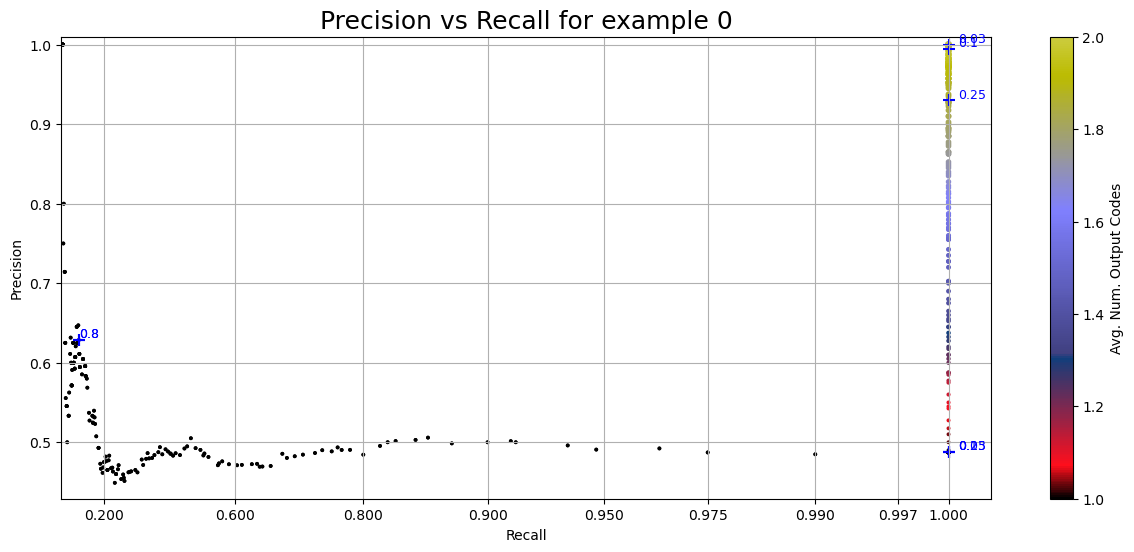

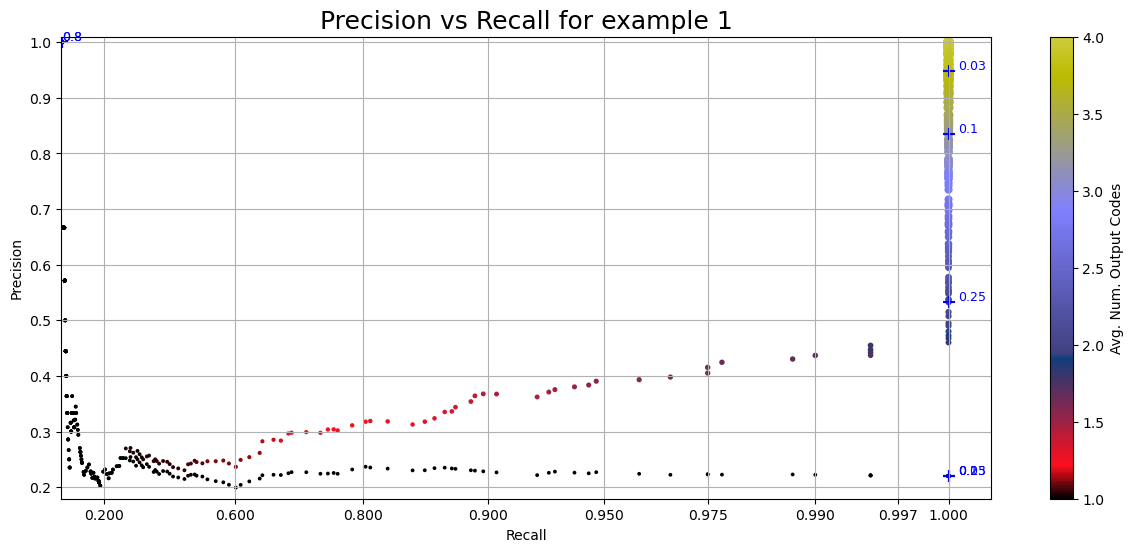

{'0': {'accuracy': 0.4875,
  'top_5_accuracy': 1.0,
  'f1_score': {'micro': 0.4875,
   'macro': 0.4874199093608376,
   'weighted': 0.4874199093608377}},
 '1': {'accuracy': 0.22,
  'top_5_accuracy': 1.0,
  'f1_score': {'micro': 0.22,
   'macro': 0.18567572328643175,
   'weighted': 0.25734807823523725}}}

In [16]:
# evaluate a model
codifier_example.evaluate(version='example')

In [17]:
# Predict
help(codifier_example.predict)

Help on method predict in module statcodgen.codifier:

predict(desc_l, mode, hierarchical_level, threshold, original_code_l=None, identifier_l=None) method of __main__.CodifierRandom instance
    Predict hierarchical classification codes for a list of descriptions.
    
    Parameters
    ----------
    desc_l : list of str
        List of textual descriptions to classify.
    mode : str
        Mode of prediction:
        - "codification": returns the top 1 predicted class.
        - "assistance": returns the top 15 predicted classes.
    hierarchical_level : int
        Target hierarchical level for which the predictions are returned.
    threshold : float
        Minimum confidence value (0-1) to include a predicted label.
    original_code_l : list, optional
        Original codes for direct recoding. If provided, predictions may be
        overridden by direct correspondences for codes that map
        unambiguously.
    identifier_l : list, optional
        Unique identifiers cor

In [18]:
# Predictions can be made on a specific level
desc_l = ['prueba']*5
mode = 'codification'
hierarchical_level = 2
threshold = 0

codifier_example.predict(
    desc_l,
    mode,
    hierarchical_level,
    threshold
)

[{'description': 'prueba',
  'original_code': None,
  'label': ('A2',),
  'confidence': (58,),
  'hierarchical_level': 2,
  'identifier': 0,
  'title': ('Grupo A2',)},
 {'description': 'prueba',
  'original_code': None,
  'label': ('B1',),
  'confidence': (33,),
  'hierarchical_level': 2,
  'identifier': 1,
  'title': ('Grupo B1',)},
 {'description': 'prueba',
  'original_code': None,
  'label': ('B1',),
  'confidence': (53,),
  'hierarchical_level': 2,
  'identifier': 2,
  'title': ('Grupo B1',)},
 {'description': 'prueba',
  'original_code': None,
  'label': ('A1',),
  'confidence': (33,),
  'hierarchical_level': 2,
  'identifier': 3,
  'title': ('Grupo A1',)},
 {'description': 'prueba',
  'original_code': None,
  'label': ('B2',),
  'confidence': (42,),
  'hierarchical_level': 2,
  'identifier': 4,
  'title': ('Grupo B2',)}]

In [18]:
# Assistance can also be requested
desc_l = ['prueba']*5
mode = 'assistance'
hierarchical_level = 1
threshold = 0

codifier_example.predict(
    desc_l,
    mode,
    hierarchical_level,
    threshold
)

[{'description': 'prueba',
  'original_code': None,
  'label': ('B', 'A'),
  'confidence': (66, 34),
  'hierarchical_level': 1,
  'identifier': 0,
  'title': ('Sección B', 'Sección A')},
 {'description': 'prueba',
  'original_code': None,
  'label': ('A', 'B'),
  'confidence': (54, 46),
  'hierarchical_level': 1,
  'identifier': 1,
  'title': ('Sección A', 'Sección B')},
 {'description': 'prueba',
  'original_code': None,
  'label': ('A', 'B'),
  'confidence': (50, 50),
  'hierarchical_level': 1,
  'identifier': 2,
  'title': ('Sección A', 'Sección B')},
 {'description': 'prueba',
  'original_code': None,
  'label': ('A', 'B'),
  'confidence': (53, 47),
  'hierarchical_level': 1,
  'identifier': 3,
  'title': ('Sección A', 'Sección B')},
 {'description': 'prueba',
  'original_code': None,
  'label': ('B', 'A'),
  'confidence': (64, 36),
  'hierarchical_level': 1,
  'identifier': 4,
  'title': ('Sección B', 'Sección A')}]

### CodifierFastText
La librería statcodgen ya dispone de una clase hija implementada que permite entrenar de manera supervisada modelos con la librería fasttext que clasifica con una estratégia bottom-up. Se puede usar el comando help para acceder a la documentación y empezar a entrenar directamente. Desde el INE ya se tiene en producción dos modelos, uno para la CNAE-2009 y otro para la CNAE-2025, generados con esta clase. A continuación se pone un ejemplo de uso para la CNAE25. 

------------------------------------------------------------------------------------------------------------------------------------------------------
### CodifierFastText
The statcodgen library already provides an implemented child class that allows supervised training of models with the fastText library that classify using a bottom-up strategy. The help command can be used to access the documentation and start training directly. At INE, two models are already in production, one for CNAE-2009 and another for CNAE-2025, both generated with this class. Below is an example of usage for CNAE-2025.

In [21]:
root_path = r''
structure_25_name = r''
train_name = r''
test_name = r''
correspondences_09_25_name = r''

structure_df = pd.read_excel(
    os.path.join(root_path, structure_25_name),
    dtype = 'str'
)
train_df = pd.read_csv(
    os.path.join(root_path, train_name),
    dtype = 'str',
    usecols=[1,2]
)
test_df = pd.read_excel(
    os.path.join(root_path, test_name),
    dtype = 'str'
)
corres_df = pd.read_excel(
    os.path.join(root_path, correspondences_09_25_name),
    dtype = 'str'
)

FileNotFoundError: [Errno 2] No such file or directory: ''

In [19]:
cnae_structure = StructuredCNAE(
    structure_df,
    ['section', 'division', 'group', 'class']
)

cnae_codifier = CodifierFastText(
    root_path=root_path,
    structure_instance=cnae_structure,
    train_df=train_df,
    test_df=test_df,
    corres_df=corres_df
)

NameError: name 'structure_df' is not defined

In [ ]:
help(cnae_codifier.train) # documentacion for train

In [ ]:
# Load a previously trained model from the path
cnae_codifier.load(
    name=r''
) 

In [ ]:
# Example of how including the original code influences the results
desc_l=[
    'venta al por menor',
    'venta al por menor'
       ]
orig_code_l = [
    None,
    '4711'
]
mode = 'assistance'
hierarchical_level = 4
threshold = 0.03

cnae_codifier.predict(
    desc_l=desc_l,
    mode=mode,
    hierarchical_level=hierarchical_level,
    threshold=threshold,
    original_code_l=orig_code_l,
)

In [ ]:
# Finally, the versatility of the library is demonstrated, showing how the CodifierRandom class can be used with CNAE
cnae_codifier_random = CodifierRandom(
    root_path=root_path,
    structure_instance=cnae_structure,
    train_df=train_df,
    test_df=test_df,
    corres_df=corres_df
)

In [ ]:
cnae_codifier_random.evaluate()

### CodifierBERT
Al igual que con la librería FastText, statcodgen también permite entrenar modelo bert, a continuación se muestra un ejemplo de entrenamiento para el estandar de ejemplo.

------------------------------------------------------------------------------------------------------------------------------------------------------
### CodifierBERT
As with the FastText library, statcodgen also allows you to train bert models. Below is an example of training for the example standard.

In [19]:
# help(CodifierBERT)

In [20]:
from statcodgen.codifier_bert import CodifierBERT
root_path = r'C:\Users\U000000\Documents\metodologia y de muestras\Programacion\Gitlab_Projects'
# Generating train_df an test_df
train_dict = {
    'label': ['A1', 'A2', 'B1', 'B2']*10,
    'probe': [
        'A1',
        'A2',
        'B1',
        'B2'
        ]*10
}

test_df = {
    'label': ['A1', 'A2', 'B1', 'B2', 'bad_code']*10,
    'probe': ['A1_prueba', 'A_prueba', 'B1_prueba', 'B_prueba', 'Fatal']*10,
    'source': ['sour1', 'sour2', 'sour1', 'sour2', 'sour3']*10
}

train_df = pd.DataFrame(train_dict)
test_df = pd.DataFrame(test_df)
# Instance CodifierBERT
cod_bert = CodifierBERT(
    root_path=root_path,
    train_df=train_df,
    test_df=test_df,
    model_id="google-bert/bert-base-multilingual-cased",
    device="cpu",
    structure_instance=structured_example,
    min_lenght_texts=0
    )

2026-09-22 12:25:24,685 - INFO - Loading train_df..
2026-09-22 12:25:24,687 - INFO - train_df raw data count: 40
2026-09-22 12:25:24,689 - INFO - train_df bad codes count: 0
2026-09-22 12:25:24,691 - INFO - train_df bad descriptions count: 0
2026-09-22 12:25:24,693 - INFO - train_df pruned data count: 40
2026-09-22 12:25:24,696 - INFO - Loading test_df..
2026-09-22 12:25:24,697 - INFO - test_df raw data count: 50
2026-09-22 12:25:24,699 - INFO - test_df bad codes count: 10
2026-09-22 12:25:24,701 - INFO - test_df bad descriptions count: 0
2026-09-22 12:25:24,702 - INFO - test_df pruned data count: 40
C:\Users\U000000\anaconda3\envs\entorno_wp_10_cluster\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [21]:
# help(cod_bert.train)

In [22]:
# Training with default values
cod_bert.train()

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/40 [00:00<?, ? examples/s]

C:\Users\U000000\anaconda3\envs\entorno_wp_10_cluster\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/38 [00:00<?, ? examples/s]

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,Top 1 Accuracy,Top 2 Accuracy
0,2.115300,1.538556,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.682200,1.442394,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000


In [ ]:
# Predicting
desc_l = ['B1', 'Soy A2']
mode = 'assistance'
hierarchical_level = 2
threshold = 0.0001
identifier_l = ['Primero', 'Segundo']

pred = cod_bert.predict(
    desc_l=desc_l,
    mode=mode,
    hierarchical_level=hierarchical_level,
    threshold = threshold,
    identifier_l=identifier_l
)

In [ ]:
pred